# ChessPublishing Atom Extraction — Working Notebook

Iterate on extraction prompt + JSONL format using real examples from the generated data.

**Input:** `data/chesspublishinga.jsonl`

---
## Setup & Data Loading

In [79]:
import os
import json
import random
import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown
from dotenv import load_dotenv

load_dotenv()

DATA_FILE = 'data/chesspublishinga.jsonl'

def parse_json_output(text):
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"include": False, "exclude_reason": "JSON parse error", "raw": text}

print(f'Data: {DATA_FILE}')

Data: data/chesspublishinga.jsonl


In [80]:
with open(DATA_FILE) as f:
    all_entries = [json.loads(line) for line in f]

# Filter out game-level comments (no move) — we only extract atoms for moves
all_entries = [e for e in all_entries if e.get('move_uci')]

print(f'Loaded {len(all_entries)} entries from {DATA_FILE}')

Loaded 1692 entries from data/chesspublishinga.jsonl


---
## Extraction Prompt & Demos

System prompt, few-shot demos, and helper functions for the extraction LLM call.

In [81]:
SYSTEM_PROMPT = """\
You extract chess move explanations from commentary into JSON.

CRITICAL: You are a COPYIST, not an analyst. Every atom must come
DIRECTLY from the commentary text. Do NOT add your own chess knowledge.
If the commentary says "attacks e3", write that. Do NOT add "which is
a key central square" or any other analysis of your own.

Output ONLY valid JSON — no text before or after.

When include=true:
{
  "include": true,
  "fen": "<the FEN>",
  "move_san": "<the move>",
  "move_uci": "<UCI>",
  "move_assessment": "<good|inaccuracy|mistake|blunder>",
  "book_commentary": "<full original commentary>",
  "reasoning": ["fact from commentary", "another fact from commentary"],
  "variation": "optional continuation line",
  "alternative": {"move": "X", "reasoning": ["..."]}
}

When include=false:
{"include": false, "exclude_reason": "why", "book_commentary": "<text>"}

move_assessment values (based on the ANNOTATOR's words, NOT your chess
judgment):
  good — annotator views the move positively or neutrally
  inaccuracy — annotator is skeptical, hints at a better option
  mistake — annotator says the move is wrong or a clear error
  blunder — annotator says the move loses immediately or is a disaster

RULES:
1. ONLY extract what the commentary SAYS. Never add facts it doesn't state.
2. Each atom must explain WHAT the move DOES — a threat it creates, a
   square it controls, a piece it activates, a plan it enables.
   "Qd4 prevents Black's rooks from reaching the central files" = good atom.
   "Nd4 is a strong resource for White" = bad (vague label, drop it).
   "Rg8 allows Black to hold on" = bad (says nothing about what Rg8 does).
3. Atoms must be about the CURRENT move, not about later moves in a
   variation. If the commentary describes what happens several moves later,
   put that in "variation", not in atoms.
4. Position evaluations are NOT atoms. "Black has an extra pawn",
   "good position", "equal", "winning" describe the resulting position,
   not what the move does. EXCLUDE if the commentary ONLY evaluates
   the position without explaining what the move achieves.
5. Drop vague labels/assessments even if mixed with good atoms.
6. EXCLUDE when commentary only shows a variation line with no explanation
   of WHY the move works. A bare line + "holds" / "nothing clear" / "wins"
   is not an explanation.
7. INCLUDE when there is at least one concrete fact about the move:
   a piece, square, threat, file, diagonal, or plan.
8. Long variations (5+ moves) go in "variation", not in atoms.
9. When "alternatives" are provided (PGN sidelines with annotations and
   continuation lines), use them to populate the "alternative" field.
   Extract reasoning atoms from the annotator's comments on each
   alternative. If there are multiple alternatives, output "alternative"
   as a list of objects.
10. "move_assessment" captures the annotator's evaluation of the move.
    Use ONLY the annotator's own sentiment from the commentary text.
"""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 2968 chars


In [82]:
# ── Demo data from chesspublishing dataset ──────────────────────────────
# 5 demos: include+good, include+inaccuracy, include+mistake,
#          exclude (vague label), exclude (position eval only)

DEMO_DATA = [
    # Demo 1: Rab8 — concrete, good move
    {
        'fen': 'r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10',
        'move_uci': 'a8b8',
        'move_san': 'Rab8',
        'annotation': 'By defending b7 Black frees his c6-knight to play ...Nd4, and prepares a tactical trick.',
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': 'Better than',
    },
    # Demo 2: Bg2 — concrete drawback, inaccuracy
    {
        'fen': 'rnbqkb1r/1p3pp1/4pn1p/1Pp5/p3p1P1/P1N5/1BPP1P1P/R2QKBNR w KQkq - 0 9',
        'move_uci': 'f1g2',
        'move_san': 'Bg2',
        'annotation': "This automatic-looking move leaves the b-pawn short of defenders - White cannot play a4 because a black pawn stands in the way!",
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': 'Now things start going crazy.',
    },
    # Demo 3: Nxd3 — loses, mistake
    {
        'fen': 'r4rk1/1p2bpp1/p1np3p/4p3/4Pn1q/1NPP1N1P/PP1B1PP1/R2QR1K1 b - - 5 14',
        'move_uci': 'f4d3',
        'move_san': 'Nxd3',
        'annotation': (
            'Nxd3 again loses since after: 27. Red1 '
            '(Black can\'t prevent Bg2-e4 winning the pinned knight.)'
        ),
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': False,
        'mainline_move': 'a5',
        'parent_comment': 'A good preparatory move, making room on a7 for the bishop.',
    },
    # Demo 4: Nc6 — vague label only, exclude
    {
        'fen': 'rn1qkbnr/pb1p1ppp/1p2p3/2p5/4PP2/1PN5/PBPP2PP/R2QKBNR b KQkq - 0 5',
        'move_uci': 'b8c6',
        'move_san': 'Nc6',
        'annotation': 'A perfectly natural move.',
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': True,
        'mainline_move': None,
        'parent_comment': None,
    },
    # Demo 5: Rae8 — position evaluation only, exclude
    {
        'fen': 'r4rk1/1p4bp/p2p4/2pP3n/4B1pP/2B2nP1/1P3PN1/3R1R1K b - - 0 28',
        'move_uci': 'a8e8',
        'move_san': 'Rae8',
        'annotation': '28...Rae8 and Black has an extra pawn and a good position.',
        'prev_moves': '',
        'context_fen': '',
        'is_mainline': False,
        'mainline_move': None,
        'parent_comment': 'also looks good, for example',
    },
]

DEMO_FENS = {d['fen'] for d in DEMO_DATA}

# ── Demo responses ───────────────────────────────────────────────────────

_DEMO_RESPONSES = [
    # Demo 1: Rab8 — good, three concrete atoms
    {
        'include': True,
        'fen': 'r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10',
        'move_san': 'Rab8',
        'move_uci': 'a8b8',
        'move_assessment': 'good',
        'reasoning': [
            'Rab8 defends the b7-pawn.',
            'By defending b7, Rab8 frees the knight on c6 to play Nd4.',
            'Rab8 prepares a tactical trick.',
        ],
    },
    # Demo 2: Bg2 — inaccuracy, concrete atoms about the drawback
    {
        'include': True,
        'fen': 'rnbqkb1r/1p3pp1/4pn1p/1Pp5/p3p1P1/P1N5/1BPP1P1P/R2QKBNR w KQkq - 0 9',
        'move_san': 'Bg2',
        'move_uci': 'f1g2',
        'move_assessment': 'inaccuracy',
        'reasoning': [
            'Bg2 leaves the pawn on b5 with too few defenders.',
            'White cannot support the b5-pawn with a4 because Black\'s pawn on a4 blocks that advance.',
        ],
    },
    # Demo 3: Nxd3 — mistake, loses material
    {
        'include': True,
        'fen': 'r4rk1/1p2bpp1/p1np3p/4p3/4Pn1q/1NPP1N1P/PP1B1PP1/R2QR1K1 b - - 5 14',
        'move_san': 'Nxd3',
        'move_uci': 'f4d3',
        'move_assessment': 'mistake',
        'reasoning': [
            'Nxd3 loses because after Red1, Black cannot prevent Bg2-e4 winning the pinned knight.',
        ],
        'variation': '27. Red1 Bg2-e4',
    },
    # Demo 4: Nc6 — excluded, vague label only
    {
        'include': False,
        'exclude_reason': 'Commentary only labels the move as "natural" — no concrete fact about what Nc6 does.',
    },
    # Demo 5: Rae8 — excluded, position evaluation only
    {
        'include': False,
        'exclude_reason': 'Commentary only evaluates the resulting position ("extra pawn", "good position") without explaining what Rae8 does.',
    },
]

print(f'Demo data: {len(DEMO_DATA)} positions')

Demo data: 5 positions


In [83]:
def build_user_prompt(entry):
    """Build user prompt: FEN + move + prev_moves + context_fen + mainline_move + parent_comment + alternatives + commentary + line."""
    board = chess.Board(entry['fen'])
    move_san = entry.get('move_san') or board.san(chess.Move.from_uci(entry['move_uci']))
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    prompt = f"FEN: {entry['fen']}\n"
    prompt += f"Move played: {move_san} ({turn})\n"

    if entry.get('prev_moves'):
        prompt += f"Previous moves: {entry['prev_moves']}\n"
    if entry.get('context_fen'):
        prompt += f"Context FEN (start of prev_moves): {entry['context_fen']}\n"

    # Variation context: what the mainline played + parent framing
    if entry.get('mainline_move'):
        prompt += f"Mainline move: {entry['mainline_move']} (this entry discusses {move_san} as an alternative)\n"
    if entry.get('parent_comment'):
        prompt += f"Parent context: \"{entry['parent_comment']}\"\n"

    # Alternatives from PGN sibling variations
    if entry.get('alternatives'):
        prompt += "\nAlternative variations from the PGN:\n"
        for alt in entry['alternatives']:
            prompt += f"  - {alt['move_san']}"
            if alt.get('annotation'):
                prompt += f": {alt['annotation']}"
            if alt.get('line'):
                prompt += f" (line: {alt['line']})"
            prompt += "\n"

    prompt += f'\nCommentary: \"{entry["annotation"]}\"\n'
    if entry.get('line'):
        prompt += f"Continuation line: {entry['line']}\n"
    return prompt


def postprocess_filter(parsed_json):
    """Post-processing filters that catch what the LLM might miss."""
    if parsed_json.get('include', True) and not parsed_json.get('reasoning'):
        return False, "no reasoning atoms extracted"
    alt = parsed_json.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        if any(not a.get('reasoning') for a in alts):
            return False, "alternative has no reasoning — likely not from commentary"
    return parsed_json.get('include', True), parsed_json.get('exclude_reason')

print('Helpers ready')

Helpers ready


In [84]:
def build_demos(demo_data, demo_responses):
    """Build few-shot demo messages from hardcoded data + responses."""
    demos = []
    for data, resp in zip(demo_data, demo_responses):
        r = {**resp, 'book_commentary': data['annotation']}
        demos.append({'role': 'user', 'content': build_user_prompt(data)})
        demos.append({'role': 'assistant', 'content': json.dumps(r, indent=2)})
    return demos


DEMOS = build_demos(DEMO_DATA, _DEMO_RESPONSES)

print(f'Demos: {len(DEMOS) // 2} examples')

# Show what goes to the LLM
for i in range(0, len(DEMOS), 2):
    n = i // 2 + 1
    print(f'\n{"="*60}')
    print(f'Demo {n} — USER:')
    print(DEMOS[i]['content'][:200] + '...')
    print(f'\nDemo {n} — ASSISTANT:')
    print(DEMOS[i+1]['content'])

Demos: 5 examples

Demo 1 — USER:
FEN: r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10
Move played: Rab8 (Black)
Parent context: "Better than"

Commentary: "By defending b7 Black frees his c6-knight to play ...Nd4, ...

Demo 1 — ASSISTANT:
{
  "include": true,
  "fen": "r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10",
  "move_san": "Rab8",
  "move_uci": "a8b8",
  "move_assessment": "good",
  "reasoning": [
    "Rab8 defends the b7-pawn.",
    "By defending b7, Rab8 frees the knight on c6 to play Nd4.",
    "Rab8 prepares a tactical trick."
  ],
  "book_commentary": "By defending b7 Black frees his c6-knight to play ...Nd4, and prepares a tactical trick."
}

Demo 2 — USER:
FEN: rnbqkb1r/1p3pp1/4pn1p/1Pp5/p3p1P1/P1N5/1BPP1P1P/R2QKBNR w KQkq - 0 9
Move played: Bg2 (White)
Parent context: "Now things start going crazy."

Commentary: "This automatic-looking move leaves the ...

Demo 2 — ASSISTANT:
{
  "include": true,
  "fen": "rnbqkb1r/1p3pp1/4pn1p/1P

In [85]:
MODEL = "Qwen/Qwen3-32B"

# Local vLLM server — OpenAI-compatible API
client = openai.OpenAI(
    base_url="http://127.0.0.1:8000/v1",
    api_key="not-needed",
)

def call_llm(messages, model=MODEL, temperature=0.3):
    resp = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_completion_tokens=2048,
        extra_body={
            "chat_template_kwargs": {"enable_thinking": False},
        },
    )
    return resp.choices[0].message.content

def generate_extraction(entry, model=MODEL):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.extend(DEMOS)
    messages.append({"role": "user", "content": build_user_prompt(entry)})
    return call_llm(messages, model=model)

print(f'Model: {MODEL} (local vLLM @ http://127.0.0.1:8000)')

Model: Qwen/Qwen3-32B (local vLLM @ http://127.0.0.1:8000)


---
## Run Extraction & Review

For each sampled position: get engine analysis, run extraction, display board + commentary + atoms.

Sampled 30 positions (seed=47)
  [0] ML Gareyev, Timur vs Duda, Jan Krzysztof — d5  (966 chars)
  [1] ML Gareyev, Timur vs Duda, Jan Krzysztof — Qxc6  (48 chars)
  [2] V(d=1) Gareyev, Timur vs Duda, Jan Krzysztof — Bg2  (354 chars)
  [3] V(d=1) Honos, Attila vs Kantor, Gergely — Rxc6  (26 chars)
  [4] ML Karpatchev, Aleksandr vs Mazur, Stefan — h6  (475 chars)
  [5] V(d=1) Larino Nieto, David vs Sumets, Andrey — h5  (34 chars)
  [6] V(d=1) Ibarra Jerez, Jose Carlos vs Sanchez Dengra, Jose Maria — Nd5  (82 chars)
  [7] V(d=2) Short, Nigel D vs Caruana, Fabiano — Nf3  (215 chars)
  [8] V(d=1) [alt to e3] Short, Nigel D vs Caruana, Fabiano — Nf3  (88 chars)
  [9] V(d=1) Collas, Didier vs Vehi Bach, Victor Manuel — Bxa4  (37 chars)
  [10] V(d=1) Minasian, Artashes vs Van Beek, Alexander — Nd3  (37 chars)
  [11] V(d=1) Minasian, Artashes vs Van Beek, Alexander — b4  (74 chars)
  [12] V(d=3) Bauer, Christian vs Isik, Engin Yasar — Nf8  (77 chars)
  [13] ML Arwanitakis, Michael vs Woeber, Fri

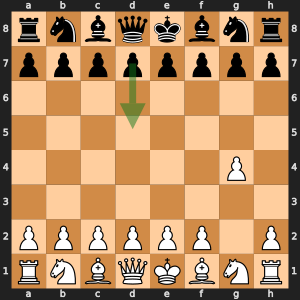

### [1/30] Gareyev, Timur vs Duda, Jan Krzysztof — Black plays d5

**Prev moves:** `1. g4 d5`

**Parent context:** *With apologies to Grob enthusiasts who may be offended by this annotation! I should note that others have been harsher, for example Victor Mikhalevski, in his excellent repertoire book for Black "Beating Minor Openings", gives it a straight "?". Nevertheless GM Gareyev played the Grob three times at the World Rapid & Blitz Championships, notching two wins and almost scoring an upset win in this game against the higher rated J-K Duda.*

**PGN alternatives:**
  - **h5**: This is the kind of reaction that Grob aficionados are likely glad to see: Black welcomes the randomness, but without getting the advantage he can secure with more classical responses..

> Black's most popular reply to the Grob, and perhaps the most logical, simply attacking the weak g4-pawn. A couple of other examples from Gareyev's practice: 2. Bg2 (This is by far the most common move, but the most loyal Grob expert, IM Michael Basman, has (for many decades) prefer...) Bxg4 (A strong move that does however, invite some complications. If Black is prepared for this opening, I think that this ...) 3. c4 d4 (A rare choice, found in only 7 games in my database. Instead Mikhalevski gives two lines that he likes for Black:) 4. Bxb7 Nd7 5. Bxa8 (White is not forced to grab the exchange, instead:) Qxa8 6. f3 e5 7. d3 f5 (The first new move, but perhaps not the best. Here Black has also played:); or 2. h3 (and after) e5 3. Bg2 (we see a mix of old and recent Basman games:) c6 (and now) 4. d4 (is White's most popular try, but Black usually gets a positional advantage with normal developing moves, for example:) Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7

...

1. d5 attacks the weak g4-pawn.

**Alternative: h5**
  - Black welcomes the randomness of the Grob.

**Variation:** `2. Bg2 Bxg4 3. c4 d4 4. Bxb7 Nd7 5. Bxa8 Qxa8 6. f3 e5 7. d3 f5; or 2. h3 e5 3. Bg2 c6 4. d4 Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqkbnr/pppppppp/8/8/6P1/8/PPPPPP1P/RNBQKBNR b KQkq - 0 1",
  "move_san": "d5",
  "move_uci": "d7d5",
  "move_assessment": "good",
  "reasoning": [
    "d5 attacks the weak g4-pawn."
  ],
  "variation": "2. Bg2 Bxg4 3. c4 d4 4. Bxb7 Nd7 5. Bxa8 Qxa8 6. f3 e5 7. d3 f5; or 2. h3 e5 3. Bg2 c6 4. d4 Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7",
  "alternative": {
    "move": "h5",
    "reasoning": [
      "Black welcomes the randomness of the Grob."
    ]
  },
  "book_commentary": "Black's most popular reply to the Grob, and perhaps the most logical, simply attacking the weak g4-pawn. A couple of other examples from Gareyev's practice: 2. Bg2 (This is by far the most common move, but the most loyal Grob expert, IM Michael Basman, has (for many decades) prefer...) Bxg4 (A strong move that does however, invite some complications. If Black is prepared for this opening, I think that this ...) 3. c4 d4 (A rare choice, found in only 7 games in my database. Instead Mikhalevski gives two lines that he likes for Black:) 4. Bxb7 Nd7 5. Bxa8 (White is not forced to grab the exchange, instead:) Qxa8 6. f3 e5 7. d3 f5 (The first new move, but perhaps not the best. Here Black has also played:); or 2. h3 (and after) e5 3. Bg2 (we see a mix of old and recent Basman games:) c6 (and now) 4. d4 (is White's most popular try, but Black usually gets a positional advantage with normal developing moves, for example:) Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7"
}
```
</details>

---

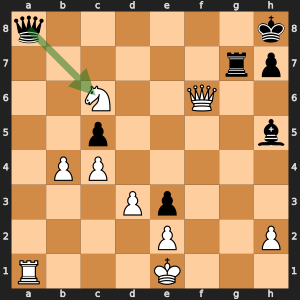

### [2/30] Gareyev, Timur vs Duda, Jan Krzysztof — Black plays Qxc6

**Prev moves:** `33. Bxf6+ Bxf6 34. Qxf6+ Rg7 35. Ra1 Qxc6`

**Parent context:** *Disaster strikes! Instead:*

> Black is now a piece up and wins in short order.

#### Extraction [EXCLUDED: Commentary only evaluates the resulting position ("piece up", "wins in short order") without explaining what Qxc6 does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only evaluates the resulting position (\"piece up\", \"wins in short order\") without explaining what Qxc6 does.",
  "book_commentary": "Black is now a piece up and wins in short order."
}
```
</details>

---

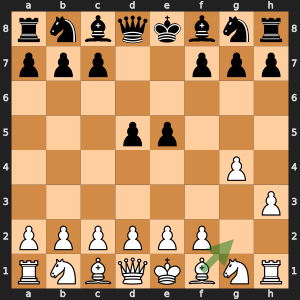

### [3/30] Gareyev, Timur vs Duda, Jan Krzysztof — White plays Bg2

**Prev moves:** `1. g4 d5 2. h3 e5 3. Bg2`

**Parent context:** *and after*

> 3. Bg2 we see a mix of old and recent Basman games: 3... c6 (and now) 4. d4 (is White's most popular try, but Black usually gets a positional advantage with normal developing moves, for example:) Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7 8. Ne4 Bc7 9. Bg5; or 3... h5 4. g5 (Basman's latest try) c6 5. d4 (and now:) exd4 6. Nf3 c5 7. c3 dxc3 8. Nxc3 Be6 9. g6

#### Extraction [EXCLUDED: Commentary only shows continuation lines without concrete facts about what Bg2 achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only shows continuation lines without concrete facts about what Bg2 achieves.",
  "book_commentary": "3. Bg2 we see a mix of old and recent Basman games: 3... c6 (and now) 4. d4 (is White's most popular try, but Black usually gets a positional advantage with normal developing moves, for example:) Nd7 5. c4 dxc4 6. Nc3 Bd6 7. Nf3 Ne7 8. Ne4 Bc7 9. Bg5; or 3... h5 4. g5 (Basman's latest try) c6 5. d4 (and now:) exd4 6. Nf3 c5 7. c3 dxc3 8. Nxc3 Be6 9. g6"
}
```
</details>

---

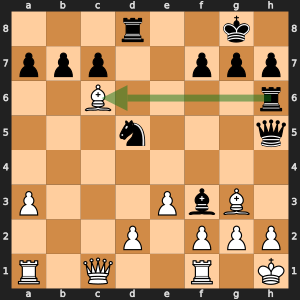

### [4/30] Honos, Attila vs Kantor, Gergely — Black plays Rxc6

**Prev moves:** `19. Bxc6 Be4 20. Be5 Bxf3 21. Bg3 Rxc6`

**Parent context:** *Not bothering to recapture, since mate in two is threatened.*

> 21...Rxc6 wins on material

#### Extraction [INCLUDED]

**Move assessment:** good

1. Rxc6 wins material.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3r2k1/ppp2ppp/2B4r/3n3q/8/P3PbB1/3P1PPP/R1Q2R1K b - - 1 21",
  "move_san": "Rxc6",
  "move_uci": "d6c6",
  "move_assessment": "good",
  "reasoning": [
    "Rxc6 wins material."
  ],
  "book_commentary": "21...Rxc6 wins on material"
}
```
</details>

---

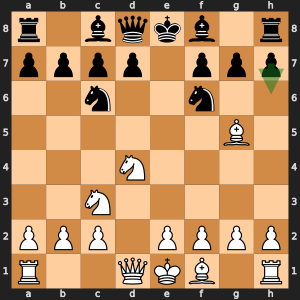

### [5/30] Karpatchev, Aleksandr vs Mazur, Stefan — Black plays h6

**Prev moves:** `3. d4 exd4 4. Nxd4 Nf6 5. Bg5 h6`

**Parent context:** *Black has also played:*

**PGN alternatives:**
  - **Be7**: 5...Be7 is even worse, since after: 6. Nf5 (Black is already struggling to defend the g7-pawn. Now) Rg8 7. e3 d5 8. Nxe7 Nxe7 9. Qd4 Be6 10. O-O-O Qd7 11. Bxf6 gxf6
  - **Bb4**: 5...Bb4 is a reliable reply. Now: 6. Nxc6 bxc6 7. Qd4 Qe7 8. Bxf6 gxf6 9. O-O-O Bc5 10. Qh4 f5 11. Qg3 (Luch,M (2446)-Espinoza Palomino,W (2342) Roquetas de Mar 2016 ½-½ (25), and now) d5 (leads to an unbalanced position where both sides have fighting chances); or 6. e3 O-O 7. Be2 h6 8. Bxf6 Bxc3+ 9. bxc3 Qxf6 (is at least equal for Black, see Ivanchuk-Anand in the Archives)

> A natural move, putting the question to the g5-bishop, but Black doesn't have time for this. Instead: 6. Bxf6 Qxf6 7. Ndb5 (As we have seen in several of the earlier notes, Black is caught out by the weakness of the c7-pawn.) Qd8 (The alternatives are no more promising:) 8. Nd5 Bb4+ 9. Nxb4 (This works out well for White, but he has an even better option here with:) Nxb4 10. Qd2 Na6 (Instead:) 11. Nxa7 (Winning a pawn through a cute tactic. Alternatively:) O-O (Instead:)

...

**Alternative: Be7**
  - 5...Be7 is even worse.

**Alternative: Bb4**
  - 5...Bb4 is a reliable reply.

**Variation:** `6. Bxf6 Qxf6 7. Ndb5 Qd8 8. Nd5 Bb4+ 9. Nxb4 Nxb4 10. Qd2 Na6 11. Nxa7`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r1bqkb1r/pppp1ppp/2n2n2/6B1/3N4/2N5/PPP1PPPP/R2QKB1R b KQkq - 2 5",
  "move_san": "h6",
  "move_uci": "h7g6",
  "move_assessment": "inaccuracy",
  "reasoning": [
    "h6 puts the question to the g5-bishop.",
    "Black doesn't have time for this move."
  ],
  "variation": "6. Bxf6 Qxf6 7. Ndb5 Qd8 8. Nd5 Bb4+ 9. Nxb4 Nxb4 10. Qd2 Na6 11. Nxa7",
  "alternative": [
    {
      "move": "Be7",
      "reasoning": [
        "5...Be7 is even worse."
      ],
      "variation": "6. Nf5 Rg8 7. e3 d5 8. Nxe7 Nxe7 9. Qd4 Be6 10. O-O-O Qd7 11. Bxf6 gxf6"
    },
    {
      "move": "Bb4",
      "reasoning": [
        "5...Bb4 is a reliable reply."
      ],
      "variation": "6. Nxc6 bxc6 7. Qd4 Qe7 8. Bxf6 gxf6 9. O-O-O Bc5 10. Qh4 f5 11. Qg3 d5"
    }
  ],
  "book_commentary": "A natural move, putting the question to the g5-bishop, but Black doesn't have time for this. Instead: 6. Bxf6 Qxf6 7. Ndb5 (As we have seen in several of the earlier notes, Black is caught out by the weakness of the c7-pawn.) Qd8 (The alternatives are no more promising:) 8. Nd5 Bb4+ 9. Nxb4 (This works out well for White, but he has an even better option here with:) Nxb4 10. Qd2 Na6 (Instead:) 11. Nxa7 (Winning a pawn through a cute tactic. Alternatively:) O-O (Instead:)"
}
```
</details>

---

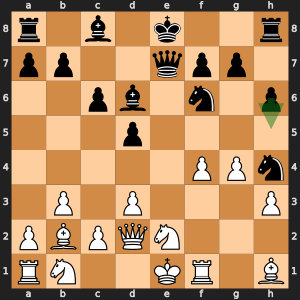

### [6/30] Larino Nieto, David vs Sumets, Andrey — Black plays h5

**Prev moves:** `11. exf4 Qe7 12. Qd2 Nh4 13. Bh1 h5`

**Parent context:** *Now White is in terrible trouble.*

> 13...h5 is also horrible for White

#### Extraction [EXCLUDED: Commentary only states that the move is bad for White without explaining what h5 does or why it causes trouble.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that the move is bad for White without explaining what h5 does or why it causes trouble.",
  "book_commentary": "13...h5 is also horrible for White"
}
```
</details>

---

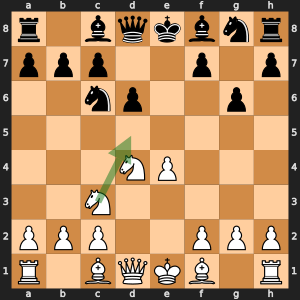

### [7/30] Ibarra Jerez, Jose Carlos vs Sanchez Dengra, Jose Maria — White plays Nd5

**Prev moves:** `3... exd4 4. Nxd4 d6 5. e4 g6 6. Nd5`

> 6. Nd5 gave White an early initiative in Rapport-Mueller, Deizisau 2014. Note that

#### Extraction [EXCLUDED: Commentary only references a game and provides no concrete explanation of what the move Nd5 achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only references a game and provides no concrete explanation of what the move Nd5 achieves.",
  "book_commentary": "6. Nd5 gave White an early initiative in Rapport-Mueller, Deizisau 2014. Note that"
}
```
</details>

---

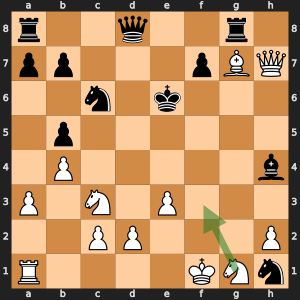

### [8/30] Short, Nigel D vs Caruana, Fabiano — White plays Nf3

**Prev moves:** `14... Nxh1 15. dxe6+ Kxe6 16. Nc3 Nc6 17. Nf3`

**Parent context:** *trying to keep the rook is not so good*

> 17. Nf3 and despite being a rook down White is better. Black's king is too exposed and his pieces are more or less hanging. For example: 17... Nf2 18. d4 Kd7 19. d5 Ne7 20. Qxh4 Rxg7 21. Kxf2 (with a huge advantage)

#### Extraction [INCLUDED]

**Move assessment:** good

1. Nf3 supports White's central play and prepares to exploit Black's exposed king.
2. Nf3 helps White maintain a strong position despite being a rook down.

**Variation:** `17... Nf2 18. d4 Kd7 19. d5 Ne7 20. Qxh4 Rxg7 21. Kxf2`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r2q2r1/pp3pBQ/2n1k3/1p6/1P5b/P1N1P3/2PP3P/R4KNn w - - 2 17",
  "move_san": "Nf3",
  "move_uci": "g1f3",
  "move_assessment": "good",
  "reasoning": [
    "Nf3 supports White's central play and prepares to exploit Black's exposed king.",
    "Nf3 helps White maintain a strong position despite being a rook down."
  ],
  "variation": "17... Nf2 18. d4 Kd7 19. d5 Ne7 20. Qxh4 Rxg7 21. Kxf2",
  "book_commentary": "17. Nf3 and despite being a rook down White is better. Black's king is too exposed and his pieces are more or less hanging. For example: 17... Nf2 18. d4 Kd7 19. d5 Ne7 20. Qxh4 Rxg7 21. Kxf2 (with a huge advantage)"
}
```
</details>

---

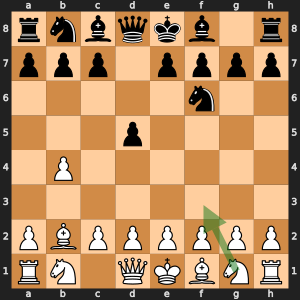

### [9/30] Short, Nigel D vs Caruana, Fabiano — White plays Nf3 (alternative to e3)

**Prev moves:** `1. b4 d5 2. Bb2 Nf6 3. Nf3`

> 3. Nf3 is normal, trying to enter a normal position with some expansion on the queenside

#### Extraction [INCLUDED]

**Move assessment:** good

1. Nf3 is a normal move.
2. Nf3 tries to enter a normal position.
3. Nf3 allows for some expansion on the queenside.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqkb1r/ppp1pppp/5n2/3p4/1P6/8/PBPPPPPP/RN1QKBNR w KQkq - 2 3",
  "move_san": "Nf3",
  "move_uci": "g1f3",
  "move_assessment": "good",
  "reasoning": [
    "Nf3 is a normal move.",
    "Nf3 tries to enter a normal position.",
    "Nf3 allows for some expansion on the queenside."
  ],
  "book_commentary": "3. Nf3 is normal, trying to enter a normal position with some expansion on the queenside"
}
```
</details>

---

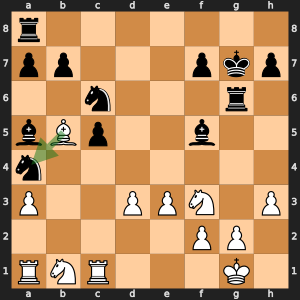

### [10/30] Collas, Didier vs Vehi Bach, Victor Manuel — White plays Bxa4

**Prev moves:** `16... Re4 17. d3 Rg4 18. h3 Rg6 19. Bxa4`

**Parent context:** *(the point behind the previous move)*

> 19. Bxa4 and White has the upper hand

#### Extraction [EXCLUDED: Commentary only states that White has the upper hand without explaining what Bxa4 does concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White has the upper hand without explaining what Bxa4 does concretely.",
  "book_commentary": "19. Bxa4 and White has the upper hand"
}
```
</details>

---

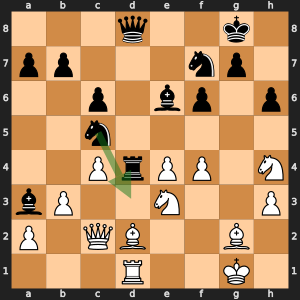

### [11/30] Minasian, Artashes vs Van Beek, Alexander — Black plays Nd3

**Prev moves:** `25. Ne3 Qd8 26. f4 exf4 27. gxf4 Nd3`

**Parent context:** *White has the more active position and the initiative.*

> 27...Nd3 opens the game unnecessarily

#### Extraction [INCLUDED]

**Move assessment:** inaccuracy

1. Nd3 opens the game unnecessarily.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3q2k1/pp3np1/2p1bp1p/2n5/2PrPP1N/bP2N2P/P1QB2B1/3R2K1 b - - 0 27",
  "move_san": "Nd3",
  "move_uci": "c5d3",
  "move_assessment": "inaccuracy",
  "reasoning": [
    "Nd3 opens the game unnecessarily."
  ],
  "book_commentary": "27...Nd3 opens the game unnecessarily"
}
```
</details>

---

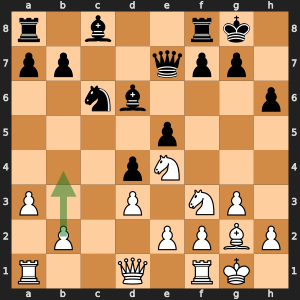

### [12/30] Minasian, Artashes vs Van Beek, Alexander — White plays b4

**Prev moves:** `10... d4 11. Ne4 Qe7 12. a3 Nc6 13. b4`

> 13. b4 and White has the initiative, Maiwald, J-Kayser, F/Dresden GER 2007

#### Extraction [EXCLUDED: Commentary only states that White has the initiative and provides tournament information, without explaining what b4 achieves concretely.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White has the initiative and provides tournament information, without explaining what b4 achieves concretely.",
  "book_commentary": "13. b4 and White has the initiative, Maiwald, J-Kayser, F/Dresden GER 2007"
}
```
</details>

---

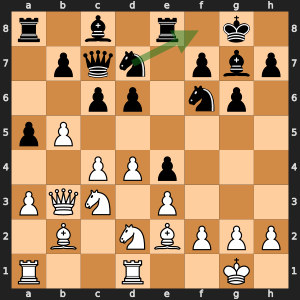

### [13/30] Bauer, Christian vs Isik, Engin Yasar — Black plays Nf8

**Prev moves:** `12. Qb3 e5 13. Rfd1 e4 14. Nd2 Nf8`

**Parent context:** *The availability of this move demonstrates the weakness in Black's idea, and demonstrates that White certainly has nothing to fear from Black's choice of variation*

> 14...Nf8 and White's chances seem preferable, Basman, M-Smith, A/Torquay 1998

#### Extraction [EXCLUDED: Commentary only states that White's chances seem preferable without explaining what Nf8 does or why it is played.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that White's chances seem preferable without explaining what Nf8 does or why it is played.",
  "book_commentary": "14...Nf8 and White's chances seem preferable, Basman, M-Smith, A/Torquay 1998"
}
```
</details>

---

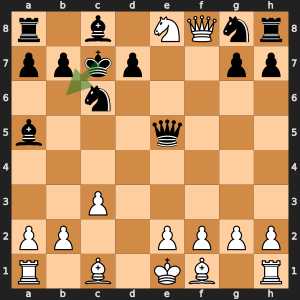

### [14/30] Arwanitakis, Michael vs Woeber, Friedrich — Black plays Kb6

**Prev moves:** `11. Qxf7+ Kd8 12. Qf8+ Kc7 13. Ne8+ Kb6`

**Parent context:** *Obviously forced.*

> Again Black has no choice.

#### Extraction [EXCLUDED: Commentary only states that Black has no choice — no concrete fact about what Kb6 does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only states that Black has no choice \u2014 no concrete fact about what Kb6 does.",
  "book_commentary": "Again Black has no choice."
}
```
</details>

---

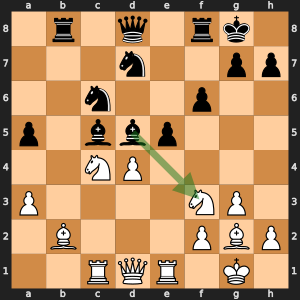

### [15/30] Minasian, Artashes vs Ramesh, Ramachandran B — Black plays Bxf3 (alternative to Nxd4)

**Prev moves:** `17. Re1 f6 18. Rc1 Rb8 19. d4 Bxf3`

**Parent context:** *can be considered, e.g.*

> 19...Bxf3 will likely reach the same position as in the main line through a little transposition

#### Extraction [INCLUDED]

**Move assessment:** good

1. Bxf3 will likely reach the same position as in the main line through a little transposition.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "1r1q1rk1/3n2pp/2n2p2/p1bbp3/2NP4/P4NP1/1B3PBP/2RQR1K1 b - - 0 19",
  "move_san": "Bxf3",
  "move_uci": "d6f3",
  "move_assessment": "good",
  "reasoning": [
    "Bxf3 will likely reach the same position as in the main line through a little transposition."
  ],
  "book_commentary": "19...Bxf3 will likely reach the same position as in the main line through a little transposition"
}
```
</details>

---

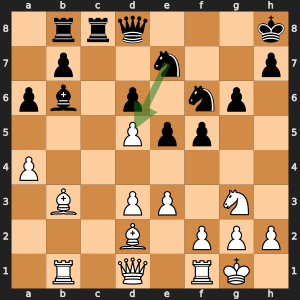

### [16/30] Sitnikov, Anton vs Aveskulov, Valeriy — Black plays Nexd5 (alternative to Ba5)

**Prev moves:** `20. Ba2 Nf6 21. Ng3 g6 22. Bb3 Nexd5`

**Parent context:** *Preventing 13...b5.*

> 22...Nexd5 with

#### Extraction [EXCLUDED: Commentary is incomplete and provides no concrete explanation of what Nexd5 achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is incomplete and provides no concrete explanation of what Nexd5 achieves.",
  "book_commentary": "22...Nexd5 with"
}
```
</details>

---

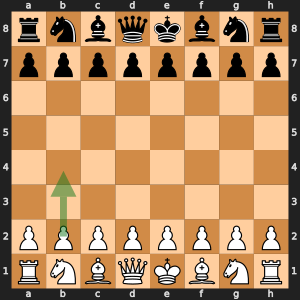

### [17/30] Carlsen, Magnus vs Nakamura, Hikaru — White plays b4

**Prev moves:** `1. b4`

> Not an opening you would expect from the World Champion, even in online rapid, and especially not in a critical knockout game. In fact, Carlsen had played the Orangutan earlier in the same tournament against Anish Giri (see the note to White's 5th move below), and repeats the same opening concept here, albeit with a slightly different move order.

#### Extraction [EXCLUDED: Commentary is purely evaluative and historical, with no concrete explanation of what the move b4 does in the position.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is purely evaluative and historical, with no concrete explanation of what the move b4 does in the position.",
  "book_commentary": "Not an opening you would expect from the World Champion, even in online rapid, and especially not in a critical knockout game. In fact, Carlsen had played the Orangutan earlier in the same tournament against Anish Giri (see the note to White's 5th move below), and repeats the same opening concept here, albeit with a slightly different move order."
}
```
</details>

---

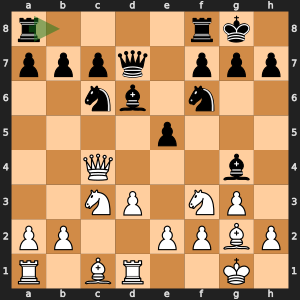

### [18/30] Azmaiparashvili, Zurab vs Mahjoob, Morteza — Black plays Rab8

**Prev moves:** `8. O-O Bg4 9. Nc3 Qd7 10. Rd1 Rab8`

**Parent context:** *Better than*

> By defending b7 Black frees his c6-knight to play ...Nd4, and prepares a tactical trick.

#### Extraction [INCLUDED]

**Move assessment:** good

1. Rab8 defends the b7-pawn.
2. By defending b7, Rab8 frees the knight on c6 to play Nd4.
3. Rab8 prepares a tactical trick.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r4rk1/pppq1ppp/2nb1n2/4p3/2Q3b1/2NP1NP1/PP2PPBP/R1BR2K1 b - - 6 10",
  "move_san": "Rab8",
  "move_uci": "a8b8",
  "move_assessment": "good",
  "reasoning": [
    "Rab8 defends the b7-pawn.",
    "By defending b7, Rab8 frees the knight on c6 to play Nd4.",
    "Rab8 prepares a tactical trick."
  ],
  "book_commentary": "By defending b7 Black frees his c6-knight to play ...Nd4, and prepares a tactical trick."
}
```
</details>

---

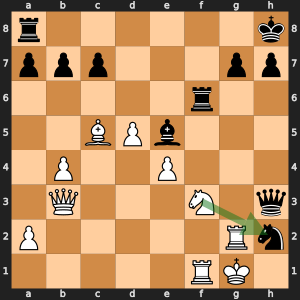

### [19/30] Miralles, Gilles vs Bologan, Viktor — White plays Nxh2 (alternative to Rxh2)

**Prev moves:** `21... Be5 22. Bc5 Rf6 23. Rg2 Nxh2 24. Nxh2`

**Parent context:** *Black plays with great precision.*

> 24. Nxh2 allows a forced mate: 24... Bxh2+ 25. Rxh2 Rxf1#

#### Extraction [INCLUDED]

**Move assessment:** blunder

1. Nxh2 allows 24... Bxh2+ followed by 25... Rxf1#.

**Variation:** `24... Bxh2+ 25. Rxh2 Rxf1#`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r6k/ppp3pp/5r2/2BPb3/1P2P3/1Q3N1q/P5Rn/5RK1 w - - 0 24",
  "move_san": "Nxh2",
  "move_uci": "g1h2",
  "move_assessment": "blunder",
  "reasoning": [
    "Nxh2 allows 24... Bxh2+ followed by 25... Rxf1#."
  ],
  "variation": "24... Bxh2+ 25. Rxh2 Rxf1#",
  "book_commentary": "24. Nxh2 allows a forced mate: 24... Bxh2+ 25. Rxh2 Rxf1#"
}
```
</details>

---

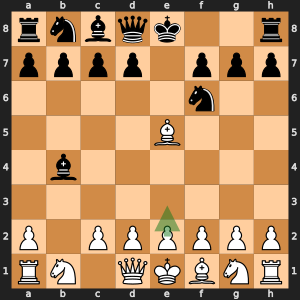

### [20/30] Hasangatin, Ramil vs Ramirez Alvarez, Alejandro — White plays e3

**Prev moves:** `1... e5 2. Bb2 Bxb4 3. Bxe5 Nf6 4. e3`

**PGN alternatives:**
  - **c4**: 4. c4 to exploit his central advantage, see Lindqvist-Soerenfors/corr 1975.

> Solid, but normally White plays more aggressively with

#### Extraction [INCLUDED]

**Move assessment:** inaccuracy

1. e3 is a solid move.

**Alternative: c4**
  - c4 exploits White's central advantage.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqk2r/pppp1ppp/5n2/4B3/1b6/8/P1PPPPPP/RN1QKBNR w KQkq - 1 4",
  "move_san": "e3",
  "move_uci": "e2e3",
  "move_assessment": "inaccuracy",
  "reasoning": [
    "e3 is a solid move."
  ],
  "alternative": {
    "move": "c4",
    "reasoning": [
      "c4 exploits White's central advantage."
    ]
  },
  "book_commentary": "Solid, but normally White plays more aggressively with"
}
```
</details>

---

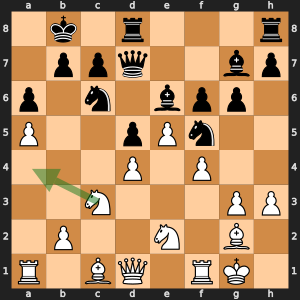

### [21/30] Minasian, Artashes vs Becerra Rivero, Julio — White plays Na4

**Prev moves:** `12... O-O-O 13. a4 Kb8 14. a5 a6 15. Na4`

**Parent context:** *A case of 'you can't make an omelette without breaking eggs'! White concedes control of b4 but judges the b5 square to be more important.*

> 15. Na4 although even here

#### Extraction [EXCLUDED: Commentary is incomplete and does not provide any concrete explanation of what Na4 does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary is incomplete and does not provide any concrete explanation of what Na4 does.",
  "book_commentary": "15. Na4 although even here"
}
```
</details>

---

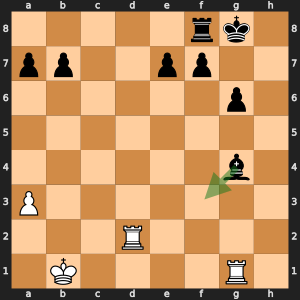

### [22/30] Morozevich, Alexander vs Kasparov, Garry — Black plays Bf3

**Prev moves:** `29. Qc2 Qd7 30. Qd2 Qxd2 31. Rxd2 Bf3`

**Parent context:** *The simplest.*

> The ending is hopeless, the four extra black pawns are much more significant than the exchange.

#### Extraction [EXCLUDED: Commentary only evaluates the resulting position ("hopeless", "four extra pawns are more significant") without explaining what Bf3 does.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary only evaluates the resulting position (\"hopeless\", \"four extra pawns are more significant\") without explaining what Bf3 does.",
  "book_commentary": "The ending is hopeless, the four extra black pawns are much more significant than the exchange."
}
```
</details>

---

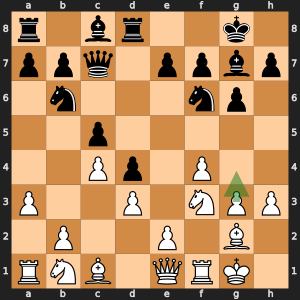

### [23/30] McDonald, Neil vs Thipsay, Praveen Mahadeo — White plays g4 (alternative to b4)

**Prev moves:** `9... Nb6 10. c4 Qc7 11. h3 Rd8 12. g4`

**Parent context:** *I had thought the knight would be badly placed on b6- I had completely missed that it can land on a4 in what follows.*

**PGN alternatives:**
  - **b4**: Still missing Black's 13th move. I should have acted on the kingside with

> 12. g4 and 13 Qh4.

...

1. g4 prepares Qh4 on the next move.

**Alternative: b4**
  - Still missing Black's 13th move. I should have acted on the kingside.

**Variation:** `13. Qh4`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r1br2k1/ppq1ppbp/1n3np1/2p5/2Pp1P2/P2P1NPP/1P2P1B1/RNB1QRK1 w - - 1 12",
  "move_san": "g4",
  "move_uci": "g2g4",
  "move_assessment": "inaccuracy",
  "reasoning": [
    "g4 prepares Qh4 on the next move."
  ],
  "variation": "13. Qh4",
  "book_commentary": "12. g4 and 13 Qh4.",
  "alternative": {
    "move": "b4",
    "reasoning": [
      "Still missing Black's 13th move. I should have acted on the kingside."
    ]
  }
}
```
</details>

---

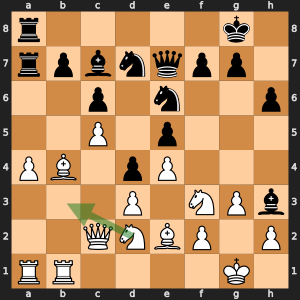

### [24/30] Dergatschova Daus, Anna vs Jussupow, Artur — White plays Nb3

**Prev moves:** `22... Ne6 23. Nd2 Rea8 24. Nef3 Qe7 25. Nb3`

**Parent context:** *White is obliged to defend his weak c-pawn.*

> White prefers to defend his c-pawn, than his a-pawn.

#### Extraction [INCLUDED]

**Move assessment:** good

1. Nb3 defends the c-pawn.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "r5k1/rpbnqpp1/2p1n2p/2P1p3/PB1pP3/3P1NPb/2QNBP1P/RR4K1 w - - 13 25",
  "move_san": "Nb3",
  "move_uci": "a1b3",
  "move_assessment": "good",
  "reasoning": [
    "Nb3 defends the c-pawn."
  ],
  "book_commentary": "White prefers to defend his c-pawn, than his a-pawn."
}
```
</details>

---

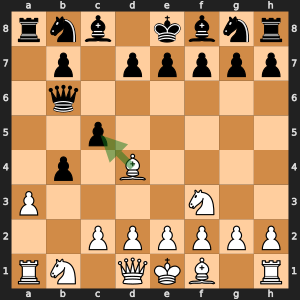

### [25/30] Ornstein, Axel vs Hansen, Sune Berg — White plays Bxc5

**Prev moves:** `3... a5 4. Nf3 axb4 5. Bd4 c5 6. Bxc5`

**Parent context:** *can be countered by*

> 6. Bxc5 winning a pawn, as: 6... Qxc5 7. axb4 (is a standard trick, winning the exchange.)

#### Extraction [INCLUDED]

**Move assessment:** good

1. Bxc5 wins a pawn after 6... Qxc5 7. axb4.

**Variation:** `6... Qxc5 7. axb4`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnb1kbnr/1p1ppppp/1q6/2p5/1p1B4/P4N2/2PPPPPP/RN1QKB1R w KQkq - 0 6",
  "move_san": "Bxc5",
  "move_uci": "c1c5",
  "move_assessment": "good",
  "reasoning": [
    "Bxc5 wins a pawn after 6... Qxc5 7. axb4."
  ],
  "variation": "6... Qxc5 7. axb4",
  "book_commentary": "6. Bxc5 winning a pawn, as: 6... Qxc5 7. axb4 (is a standard trick, winning the exchange.)"
}
```
</details>

---

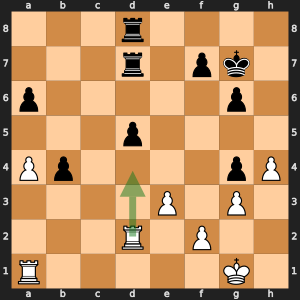

### [26/30] Ivanchuk, Vassily vs Anand, Viswanathan — White plays Rd4

**Prev moves:** `39... b4 40. cxb4 Qxa1 41. Rxa1 cxb4 42. Rd4`

**Parent context:** *Exchanging queens, and bringing play to a rook and pawn ending.*

> Forking the g and b-pawns, has Black blundered?

#### Extraction [INCLUDED]

**Move assessment:** blunder

1. Rd4 forks the g-pawn and b-pawn.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "3r4/3r1pk1/p5p1/3p4/Pp4pP/4P1P1/3R1P2/R5K1 w - - 0 42",
  "move_san": "Rd4",
  "move_uci": "a1d4",
  "move_assessment": "blunder",
  "reasoning": [
    "Rd4 forks the g-pawn and b-pawn."
  ],
  "book_commentary": "Forking the g and b-pawns, has Black blundered?"
}
```
</details>

---

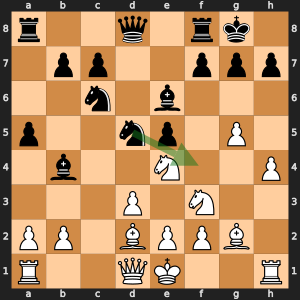

### [27/30] Basman, Michael J vs Bellin, Robert — Black plays Nf4

**Prev moves:** `10. cxd5 Nxd5 11. Ne4 Bb4+ 12. Bd2 Nf4`

**Parent context:** *as he needs this piece to protect his weak dark squares, Black would answer*

> Anyway, White is hardly likely to castle kingside, anyway.

#### Extraction [EXCLUDED: Commentary makes a general statement about White's castling and does not explain what Nf4 achieves.]

<details><summary>Full JSON</summary>

```json
{
  "include": false,
  "exclude_reason": "Commentary makes a general statement about White's castling and does not explain what Nf4 achieves.",
  "book_commentary": "Anyway, White is hardly likely to castle kingside, anyway."
}
```
</details>

---

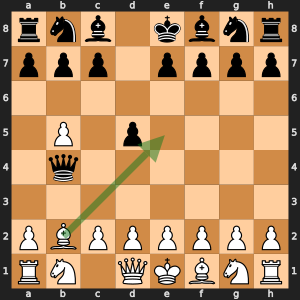

### [28/30] Lalic, Bogdan vs Uhlmann, Wolfgang — White plays Be5

**Prev moves:** `1... d5 2. Bb2 Qd6 3. b5 Qb4 4. Be5`

**Parent context:** *A very ambitious move, suggested by Andersson, attacking the b4-pawn, and preparing ...e5.*

> 4. Be5 but, after: 4... Qxb5 5. Bxc7 Qc5 6. Bg3 Nc6 (Black appears to have the edge, as ...e5 is threatened.)

#### Extraction [INCLUDED]

**Move assessment:** good

1. Be5 attacks the pawn on b4.
2. Be5 prepares ...e5 for Black.

**Variation:** `4... Qxb5 5. Bxc7 Qc5 6. Bg3 Nc6`

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnb1kbnr/ppp1pppp/8/1P1p4/1q6/8/PBPPPPPP/RN1QKBNR w KQkq - 1 4",
  "move_san": "Be5",
  "move_uci": "f1e5",
  "move_assessment": "good",
  "reasoning": [
    "Be5 attacks the pawn on b4.",
    "Be5 prepares ...e5 for Black."
  ],
  "variation": "4... Qxb5 5. Bxc7 Qc5 6. Bg3 Nc6",
  "book_commentary": "4. Be5 but, after: 4... Qxb5 5. Bxc7 Qc5 6. Bg3 Nc6 (Black appears to have the edge, as ...e5 is threatened.)"
}
```
</details>

---

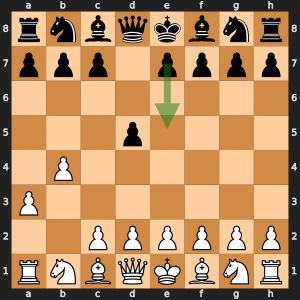

### [29/30] Lalic, Bogdan vs Uhlmann, Wolfgang — Black plays e5

**Prev moves:** `1. b4 d5 2. a3 e5`

**Parent context:** *takes provocation too far, Black would reply*

> 2...e5 with a strong centre as in the Hebden game, mentioned in the notes to ??

#### Extraction [INCLUDED]

**Move assessment:** good

1. e5 creates a strong centre.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnbqkbnr/ppp1pppp/8/3p4/1P6/P7/2PPPPPP/RNBQKBNR b KQkq - 0 2",
  "move_san": "e5",
  "move_uci": "e7e5",
  "move_assessment": "good",
  "reasoning": [
    "e5 creates a strong centre."
  ],
  "book_commentary": "2...e5 with a strong centre as in the Hebden game, mentioned in the notes to ??"
}
```
</details>

---

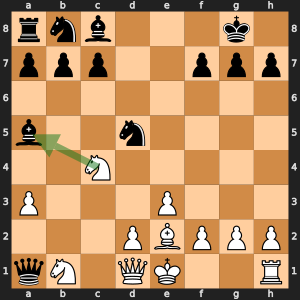

### [30/30] Linqvist, Grels vs Sorenfors, Per — White plays Nxa5

**Prev moves:** `9... Rxe5 10. Nxe5 Qf6 11. Nc4 Qxa1 12. Nxa5`

**Parent context:** *is now met by*

> 12. Nxa5 so Black should play something else at move nine, like 9...c5, with an edge.

#### Extraction [INCLUDED]

**Move assessment:** inaccuracy

1. Nxa5 suggests that Black should have played a different move earlier (9...c5) to maintain an edge.

**Alternative: 9...c5**
  - 9...c5 would give Black an edge.

<details><summary>Full JSON</summary>

```json
{
  "include": true,
  "fen": "rnb3k1/ppp2ppp/8/b2n4/2N5/P3P3/3PBPPP/qN1QK2R w K - 0 12",
  "move_san": "Nxa5",
  "move_uci": "c4a5",
  "move_assessment": "inaccuracy",
  "reasoning": [
    "Nxa5 suggests that Black should have played a different move earlier (9...c5) to maintain an edge."
  ],
  "alternative": {
    "move": "9...c5",
    "reasoning": [
      "9...c5 would give Black an edge."
    ]
  },
  "book_commentary": "12. Nxa5 so Black should play something else at move nine, like 9...c5, with an edge."
}
```
</details>

---

In [86]:
# ── Config (change these and re-run just this cell) ──
SEED = 47
NUM_POSITIONS = 30

rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_entries)), NUM_POSITIONS)
samples = [all_entries[i] for i in sorted(sample_indices)]

print(f'Sampled {NUM_POSITIONS} positions (seed={SEED})')
for i, e in enumerate(samples):
    tag = 'ML' if e['is_mainline'] else f'V(d={e["variation_depth"]})'
    ml = f' [alt to {e["mainline_move"]}]' if e.get('mainline_move') else ''
    print(f'  [{i}] {tag}{ml} {e["game"]} — {e["move_san"]}  ({len(e["annotation"])} chars)')

for idx, entry in enumerate(samples):
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'

    # Run extraction
    raw_text = generate_extraction(entry)
    parsed = parse_json_output(raw_text)

    # Post-process filter
    pp_include, pp_reason = postprocess_filter(parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason

    # ── Display ──
    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)], size=300)
    display(SVG(svg))

    meta = entry.get('metadata', {})
    game = meta.get('White', '?') + ' vs ' + meta.get('Black', '?')

    # Title with variation info
    title = f'### [{idx+1}/{len(samples)}] {game} — {turn} plays {move_san}'
    if entry.get('mainline_move'):
        title += f' (alternative to {entry["mainline_move"]})'
    display(Markdown(title))

    if entry.get('prev_moves'):
        display(Markdown(f'**Prev moves:** `{entry["prev_moves"]}`'))

    if entry.get('parent_comment'):
        display(Markdown(f'**Parent context:** *{entry["parent_comment"]}*'))

    # Show PGN alternatives (input context)
    if entry.get('alternatives'):
        alt_lines = []
        for a in entry['alternatives']:
            line = f'  - **{a["move_san"]}**'
            if a.get('annotation'):
                line += f': {a["annotation"]}'
            if a.get('line'):
                line += f' *(line: {a["line"]})*'
            alt_lines.append(line)
        display(Markdown('**PGN alternatives:**\n' + '\n'.join(alt_lines)))

    display(Markdown(f'> {entry["annotation"]}'))

    if entry.get('line'):
        display(Markdown(f'**Continuation line:** `{entry["line"]}`'))

    # Extraction result
    included = parsed.get('include', False)
    tag = 'INCLUDED' if included else f'EXCLUDED: {parsed.get("exclude_reason", "?")}'
    display(Markdown(f'#### Extraction [{tag}]'))

    if parsed.get('move_assessment'):
        display(Markdown(f'**Move assessment:** {parsed["move_assessment"]}'))

    reasoning = parsed.get('reasoning', [])
    if reasoning:
        display(Markdown('\n'.join(f'{i+1}. {a}' for i, a in enumerate(reasoning))))

    alt = parsed.get('alternative')
    if alt:
        alts = alt if isinstance(alt, list) else [alt]
        for a in alts:
            r_list = a.get('reasoning', [])
            display(Markdown(
                f'**Alternative: {a.get("move", "?")}**\n' +
                '\n'.join(f'  - {r}' for r in r_list)
            ))

    if parsed.get('variation'):
        display(Markdown(f'**Variation:** `{parsed["variation"]}`'))

    # Full structured JSON
    display(Markdown(f'<details><summary>Full JSON</summary>\n\n```json\n{json.dumps(parsed, indent=2)}\n```\n</details>'))

    display(Markdown('---'))